In [1]:
from keras import layers
from keras import Input
from keras.models import Model

import numpy as np
import tqdm
import keras    
import tensorflow as tf
import os
import csv
import pathlib
import unicode

from PIL import Image

import onnx
import tf2onnx

#from tensorflow.python.keras.preprocessing.image import ImageDataGenerator

2024-06-17 08:15:09.209836: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-06-17 08:15:09.910728: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
ja2label = {'ㄱ':0, 'ㄲ':1, 'ㄴ':2, 'ㄷ':3, 'ㄸ':4, 'ㄹ':5, 'ㅁ':6, 'ㅂ':7, 'ㅃ':8,
'ㅅ':9, 'ㅆ':10, 'ㅇ':11,  'ㅈ':12, 'ㅉ':13, 'ㅊ':14, 'ㅋ':15, 'ㅌ':16,  'ㅍ':17, 'ㅎ':18,
'0':19, '1':20, '2':21, '3':22, '4':23, '5':24, '6':25, '7':26, '8':27, '9':28, '-':29}

mo2label = {'ㅏ':0, 'ㅐ':1, 'ㅑ':2, 'ㅒ':3, 'ㅓ':4, 'ㅔ':5, 'ㅕ':6, 'ㅖ':7, 'ㅗ':8, 'ㅘ':9, 
'ㅙ':10, 'ㅚ':11, 'ㅛ':12, 'ㅜ':13, 'ㅝ':14, 'ㅞ':15, 'ㅟ':16, 'ㅠ':17, 'ㅡ':18, 'ㅢ':19, 'ㅣ':20, None:21}

ba2label = {None:0, 'ㄱ':1, 'ㄲ':2, 'ㄳ':3, 'ㄴ':4, 'ㄵ':5, 'ㄶ':6, 'ㄷ':7, 'ㄹ':8, 'ㄺ':9,
'ㄻ':10, 'ㄼ':11, 'ㄽ':12, 'ㄾ':13, 'ㄿ':14, 'ㅀ':15, 'ㅁ':16, 'ㅂ':17, 'ㅄ':18, 'ㅅ':19,
'ㅆ':20, 'ㅇ':21, 'ㅈ':22, 'ㅊ':23, 'ㅋ':24, 'ㅌ':25, 'ㅍ':26, 'ㅎ':27}

label2ja = {0: 'ㄱ', 1: 'ㄲ', 2: 'ㄴ', 3: 'ㄷ', 4: 'ㄸ', 5: 'ㄹ',
            6: 'ㅁ', 7: 'ㅂ', 8: 'ㅃ', 9: 'ㅅ', 10: 'ㅆ', 11: 'ㅇ',
            12: 'ㅈ', 13: 'ㅉ', 14: 'ㅊ', 15: 'ㅋ', 16: 'ㅌ', 17: 'ㅍ', 18: 'ㅎ',
            19: '0', 20:'1', 21:'2', 22:'3', 23:'4', 24:'5', 25:'6', 26:'7', 27:'8', 28:'9', 29:'-'}

label2mo = {0: 'ㅏ', 1: 'ㅐ', 2: 'ㅑ', 3: 'ㅒ', 4: 'ㅓ', 5: 'ㅔ',
            6: 'ㅕ', 7: 'ㅖ', 8: 'ㅗ', 9: 'ㅘ', 10: 'ㅙ', 11: 'ㅚ',
            12: 'ㅛ', 13: 'ㅜ', 14: 'ㅝ', 15: 'ㅞ', 16: 'ㅟ', 17: 'ㅠ',
            18: 'ㅡ', 19: 'ㅢ', 20: 'ㅣ', 21:None}

label2ba = {0: None, 1: 'ㄱ', 2: 'ㄲ', 3: 'ㄳ', 4: 'ㄴ', 5: 'ㄵ',
            6: 'ㄶ', 7: 'ㄷ', 8: 'ㄹ', 9: 'ㄺ', 10: 'ㄻ', 11: 'ㄼ',
            12: 'ㄽ', 13: 'ㄾ', 14: 'ㄿ', 15: 'ㅀ', 16: 'ㅁ', 17: 'ㅂ',
            18: 'ㅄ', 19: 'ㅅ', 20: 'ㅆ', 21: 'ㅇ', 22: 'ㅈ', 23: 'ㅊ',
            24: 'ㅋ', 25: 'ㅌ', 26: 'ㅍ', 27: 'ㅎ'}

In [3]:
#model = keras.models.load_model('./handwriteModeling1_12_2.keras')
model = keras.models.load_model('./vit_test.keras')

TypeError: <class 'keras.src.models.functional.Functional'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras.src.models.functional', 'class_name': 'Functional', 'config': {'name': 'functional_1', 'trainable': True, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': [None, 64, 64, 3], 'dtype': 'float32', 'sparse': False, 'name': 'input_layer'}, 'registered_name': None, 'name': 'input_layer', 'inbound_nodes': []}, {'module': None, 'class_name': 'Patches', 'config': {'name': 'patches', 'trainable': True, 'dtype': 'float32', 'patch_size': 8}, 'registered_name': 'Patches', 'build_config': {'input_shape': [None, 64, 64, 3]}, 'name': 'patches', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64, 3], 'dtype': 'float32', 'keras_history': ['input_layer', 0, 0]}}], 'kwargs': {}}]}, {'module': None, 'class_name': 'PatchEncoder', 'config': {'name': 'patch_encoder', 'trainable': True, 'dtype': 'float32', 'num_patches': 64}, 'registered_name': 'PatchEncoder', 'build_config': {'input_shape': [None, 64, 192]}, 'name': 'patch_encoder', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 192], 'dtype': 'float32', 'keras_history': ['patches', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'LayerNormalization', 'config': {'name': 'layer_normalization', 'trainable': True, 'dtype': 'float32', 'axis': [-1], 'epsilon': 1e-06, 'center': True, 'scale': True, 'beta_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'gamma_initializer': {'module': 'keras.initializers', 'class_name': 'Ones', 'config': {}, 'registered_name': None}, 'beta_regularizer': None, 'gamma_regularizer': None, 'beta_constraint': None, 'gamma_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 64]}, 'name': 'layer_normalization', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['patch_encoder', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'MultiHeadAttention', 'config': {'name': 'multi_head_attention', 'trainable': True, 'dtype': 'float32', 'num_heads': 4, 'key_dim': 64, 'value_dim': 64, 'dropout': 0.1, 'use_bias': True, 'output_shape': None, 'attention_axes': [1], 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'activity_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'shapes_dict': {'query_shape': [None, 64, 64], 'value_shape': [None, 64, 64]}}, 'name': 'multi_head_attention', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['layer_normalization', 0, 0]}}, {'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['layer_normalization', 0, 0]}}], 'kwargs': {'query_mask': None, 'value_mask': None}}]}, {'module': 'keras.layers', 'class_name': 'Add', 'config': {'name': 'add', 'trainable': True, 'dtype': 'float32'}, 'registered_name': None, 'build_config': {'input_shape': [[None, 64, 64], [None, 64, 64]]}, 'name': 'add', 'inbound_nodes': [{'args': [[{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['multi_head_attention', 0, 0]}}, {'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['patch_encoder', 0, 0]}}]], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'LayerNormalization', 'config': {'name': 'layer_normalization_1', 'trainable': True, 'dtype': 'float32', 'axis': [-1], 'epsilon': 1e-06, 'center': True, 'scale': True, 'beta_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'gamma_initializer': {'module': 'keras.initializers', 'class_name': 'Ones', 'config': {}, 'registered_name': None}, 'beta_regularizer': None, 'gamma_regularizer': None, 'beta_constraint': None, 'gamma_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 64]}, 'name': 'layer_normalization_1', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['add', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'dense_1', 'trainable': True, 'dtype': 'float32', 'units': 128, 'activation': 'gelu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 64]}, 'name': 'dense_1', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['layer_normalization_1', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dropout', 'config': {'name': 'dropout_1', 'trainable': True, 'dtype': 'float32', 'rate': 0.1, 'seed': None, 'noise_shape': None}, 'registered_name': None, 'name': 'dropout_1', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 128], 'dtype': 'float32', 'keras_history': ['dense_1', 0, 0]}}], 'kwargs': {'training': False}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'dense_2', 'trainable': True, 'dtype': 'float32', 'units': 64, 'activation': 'gelu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 128]}, 'name': 'dense_2', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 128], 'dtype': 'float32', 'keras_history': ['dropout_1', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dropout', 'config': {'name': 'dropout_2', 'trainable': True, 'dtype': 'float32', 'rate': 0.1, 'seed': None, 'noise_shape': None}, 'registered_name': None, 'name': 'dropout_2', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['dense_2', 0, 0]}}], 'kwargs': {'training': False}}]}, {'module': 'keras.layers', 'class_name': 'Add', 'config': {'name': 'add_1', 'trainable': True, 'dtype': 'float32'}, 'registered_name': None, 'build_config': {'input_shape': [[None, 64, 64], [None, 64, 64]]}, 'name': 'add_1', 'inbound_nodes': [{'args': [[{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['dropout_2', 0, 0]}}, {'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['add', 0, 0]}}]], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'LayerNormalization', 'config': {'name': 'layer_normalization_2', 'trainable': True, 'dtype': 'float32', 'axis': [-1], 'epsilon': 1e-06, 'center': True, 'scale': True, 'beta_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'gamma_initializer': {'module': 'keras.initializers', 'class_name': 'Ones', 'config': {}, 'registered_name': None}, 'beta_regularizer': None, 'gamma_regularizer': None, 'beta_constraint': None, 'gamma_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 64]}, 'name': 'layer_normalization_2', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['add_1', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'MultiHeadAttention', 'config': {'name': 'multi_head_attention_1', 'trainable': True, 'dtype': 'float32', 'num_heads': 4, 'key_dim': 64, 'value_dim': 64, 'dropout': 0.1, 'use_bias': True, 'output_shape': None, 'attention_axes': [1], 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'activity_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'shapes_dict': {'query_shape': [None, 64, 64], 'value_shape': [None, 64, 64]}}, 'name': 'multi_head_attention_1', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['layer_normalization_2', 0, 0]}}, {'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['layer_normalization_2', 0, 0]}}], 'kwargs': {'query_mask': None, 'value_mask': None}}]}, {'module': 'keras.layers', 'class_name': 'Add', 'config': {'name': 'add_2', 'trainable': True, 'dtype': 'float32'}, 'registered_name': None, 'build_config': {'input_shape': [[None, 64, 64], [None, 64, 64]]}, 'name': 'add_2', 'inbound_nodes': [{'args': [[{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['multi_head_attention_1', 0, 0]}}, {'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['add_1', 0, 0]}}]], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'LayerNormalization', 'config': {'name': 'layer_normalization_3', 'trainable': True, 'dtype': 'float32', 'axis': [-1], 'epsilon': 1e-06, 'center': True, 'scale': True, 'beta_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'gamma_initializer': {'module': 'keras.initializers', 'class_name': 'Ones', 'config': {}, 'registered_name': None}, 'beta_regularizer': None, 'gamma_regularizer': None, 'beta_constraint': None, 'gamma_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 64]}, 'name': 'layer_normalization_3', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['add_2', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'dense_3', 'trainable': True, 'dtype': 'float32', 'units': 128, 'activation': 'gelu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 64]}, 'name': 'dense_3', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['layer_normalization_3', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dropout', 'config': {'name': 'dropout_4', 'trainable': True, 'dtype': 'float32', 'rate': 0.1, 'seed': None, 'noise_shape': None}, 'registered_name': None, 'name': 'dropout_4', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 128], 'dtype': 'float32', 'keras_history': ['dense_3', 0, 0]}}], 'kwargs': {'training': False}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'dense_4', 'trainable': True, 'dtype': 'float32', 'units': 64, 'activation': 'gelu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 128]}, 'name': 'dense_4', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 128], 'dtype': 'float32', 'keras_history': ['dropout_4', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dropout', 'config': {'name': 'dropout_5', 'trainable': True, 'dtype': 'float32', 'rate': 0.1, 'seed': None, 'noise_shape': None}, 'registered_name': None, 'name': 'dropout_5', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['dense_4', 0, 0]}}], 'kwargs': {'training': False}}]}, {'module': 'keras.layers', 'class_name': 'Add', 'config': {'name': 'add_3', 'trainable': True, 'dtype': 'float32'}, 'registered_name': None, 'build_config': {'input_shape': [[None, 64, 64], [None, 64, 64]]}, 'name': 'add_3', 'inbound_nodes': [{'args': [[{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['dropout_5', 0, 0]}}, {'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['add_2', 0, 0]}}]], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'LayerNormalization', 'config': {'name': 'layer_normalization_4', 'trainable': True, 'dtype': 'float32', 'axis': [-1], 'epsilon': 1e-06, 'center': True, 'scale': True, 'beta_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'gamma_initializer': {'module': 'keras.initializers', 'class_name': 'Ones', 'config': {}, 'registered_name': None}, 'beta_regularizer': None, 'gamma_regularizer': None, 'beta_constraint': None, 'gamma_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 64]}, 'name': 'layer_normalization_4', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['add_3', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'MultiHeadAttention', 'config': {'name': 'multi_head_attention_2', 'trainable': True, 'dtype': 'float32', 'num_heads': 4, 'key_dim': 64, 'value_dim': 64, 'dropout': 0.1, 'use_bias': True, 'output_shape': None, 'attention_axes': [1], 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'activity_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'shapes_dict': {'query_shape': [None, 64, 64], 'value_shape': [None, 64, 64]}}, 'name': 'multi_head_attention_2', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['layer_normalization_4', 0, 0]}}, {'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['layer_normalization_4', 0, 0]}}], 'kwargs': {'query_mask': None, 'value_mask': None}}]}, {'module': 'keras.layers', 'class_name': 'Add', 'config': {'name': 'add_4', 'trainable': True, 'dtype': 'float32'}, 'registered_name': None, 'build_config': {'input_shape': [[None, 64, 64], [None, 64, 64]]}, 'name': 'add_4', 'inbound_nodes': [{'args': [[{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['multi_head_attention_2', 0, 0]}}, {'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['add_3', 0, 0]}}]], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'LayerNormalization', 'config': {'name': 'layer_normalization_5', 'trainable': True, 'dtype': 'float32', 'axis': [-1], 'epsilon': 1e-06, 'center': True, 'scale': True, 'beta_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'gamma_initializer': {'module': 'keras.initializers', 'class_name': 'Ones', 'config': {}, 'registered_name': None}, 'beta_regularizer': None, 'gamma_regularizer': None, 'beta_constraint': None, 'gamma_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 64]}, 'name': 'layer_normalization_5', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['add_4', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'dense_5', 'trainable': True, 'dtype': 'float32', 'units': 128, 'activation': 'gelu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 64]}, 'name': 'dense_5', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['layer_normalization_5', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dropout', 'config': {'name': 'dropout_7', 'trainable': True, 'dtype': 'float32', 'rate': 0.1, 'seed': None, 'noise_shape': None}, 'registered_name': None, 'name': 'dropout_7', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 128], 'dtype': 'float32', 'keras_history': ['dense_5', 0, 0]}}], 'kwargs': {'training': False}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'dense_6', 'trainable': True, 'dtype': 'float32', 'units': 64, 'activation': 'gelu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 128]}, 'name': 'dense_6', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 128], 'dtype': 'float32', 'keras_history': ['dropout_7', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dropout', 'config': {'name': 'dropout_8', 'trainable': True, 'dtype': 'float32', 'rate': 0.1, 'seed': None, 'noise_shape': None}, 'registered_name': None, 'name': 'dropout_8', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['dense_6', 0, 0]}}], 'kwargs': {'training': False}}]}, {'module': 'keras.layers', 'class_name': 'Add', 'config': {'name': 'add_5', 'trainable': True, 'dtype': 'float32'}, 'registered_name': None, 'build_config': {'input_shape': [[None, 64, 64], [None, 64, 64]]}, 'name': 'add_5', 'inbound_nodes': [{'args': [[{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['dropout_8', 0, 0]}}, {'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['add_4', 0, 0]}}]], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'LayerNormalization', 'config': {'name': 'layer_normalization_6', 'trainable': True, 'dtype': 'float32', 'axis': [-1], 'epsilon': 1e-06, 'center': True, 'scale': True, 'beta_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'gamma_initializer': {'module': 'keras.initializers', 'class_name': 'Ones', 'config': {}, 'registered_name': None}, 'beta_regularizer': None, 'gamma_regularizer': None, 'beta_constraint': None, 'gamma_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 64]}, 'name': 'layer_normalization_6', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['add_5', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'MultiHeadAttention', 'config': {'name': 'multi_head_attention_3', 'trainable': True, 'dtype': 'float32', 'num_heads': 4, 'key_dim': 64, 'value_dim': 64, 'dropout': 0.1, 'use_bias': True, 'output_shape': None, 'attention_axes': [1], 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'activity_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'shapes_dict': {'query_shape': [None, 64, 64], 'value_shape': [None, 64, 64]}}, 'name': 'multi_head_attention_3', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['layer_normalization_6', 0, 0]}}, {'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['layer_normalization_6', 0, 0]}}], 'kwargs': {'query_mask': None, 'value_mask': None}}]}, {'module': 'keras.layers', 'class_name': 'Add', 'config': {'name': 'add_6', 'trainable': True, 'dtype': 'float32'}, 'registered_name': None, 'build_config': {'input_shape': [[None, 64, 64], [None, 64, 64]]}, 'name': 'add_6', 'inbound_nodes': [{'args': [[{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['multi_head_attention_3', 0, 0]}}, {'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['add_5', 0, 0]}}]], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'LayerNormalization', 'config': {'name': 'layer_normalization_7', 'trainable': True, 'dtype': 'float32', 'axis': [-1], 'epsilon': 1e-06, 'center': True, 'scale': True, 'beta_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'gamma_initializer': {'module': 'keras.initializers', 'class_name': 'Ones', 'config': {}, 'registered_name': None}, 'beta_regularizer': None, 'gamma_regularizer': None, 'beta_constraint': None, 'gamma_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 64]}, 'name': 'layer_normalization_7', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['add_6', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'dense_7', 'trainable': True, 'dtype': 'float32', 'units': 128, 'activation': 'gelu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 64]}, 'name': 'dense_7', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['layer_normalization_7', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dropout', 'config': {'name': 'dropout_10', 'trainable': True, 'dtype': 'float32', 'rate': 0.1, 'seed': None, 'noise_shape': None}, 'registered_name': None, 'name': 'dropout_10', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 128], 'dtype': 'float32', 'keras_history': ['dense_7', 0, 0]}}], 'kwargs': {'training': False}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'dense_8', 'trainable': True, 'dtype': 'float32', 'units': 64, 'activation': 'gelu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 128]}, 'name': 'dense_8', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 128], 'dtype': 'float32', 'keras_history': ['dropout_10', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dropout', 'config': {'name': 'dropout_11', 'trainable': True, 'dtype': 'float32', 'rate': 0.1, 'seed': None, 'noise_shape': None}, 'registered_name': None, 'name': 'dropout_11', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['dense_8', 0, 0]}}], 'kwargs': {'training': False}}]}, {'module': 'keras.layers', 'class_name': 'Add', 'config': {'name': 'add_7', 'trainable': True, 'dtype': 'float32'}, 'registered_name': None, 'build_config': {'input_shape': [[None, 64, 64], [None, 64, 64]]}, 'name': 'add_7', 'inbound_nodes': [{'args': [[{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['dropout_11', 0, 0]}}, {'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['add_6', 0, 0]}}]], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'LayerNormalization', 'config': {'name': 'layer_normalization_8', 'trainable': True, 'dtype': 'float32', 'axis': [-1], 'epsilon': 1e-06, 'center': True, 'scale': True, 'beta_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'gamma_initializer': {'module': 'keras.initializers', 'class_name': 'Ones', 'config': {}, 'registered_name': None}, 'beta_regularizer': None, 'gamma_regularizer': None, 'beta_constraint': None, 'gamma_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 64]}, 'name': 'layer_normalization_8', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['add_7', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'MultiHeadAttention', 'config': {'name': 'multi_head_attention_4', 'trainable': True, 'dtype': 'float32', 'num_heads': 4, 'key_dim': 64, 'value_dim': 64, 'dropout': 0.1, 'use_bias': True, 'output_shape': None, 'attention_axes': [1], 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'activity_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'shapes_dict': {'query_shape': [None, 64, 64], 'value_shape': [None, 64, 64]}}, 'name': 'multi_head_attention_4', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['layer_normalization_8', 0, 0]}}, {'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['layer_normalization_8', 0, 0]}}], 'kwargs': {'query_mask': None, 'value_mask': None}}]}, {'module': 'keras.layers', 'class_name': 'Add', 'config': {'name': 'add_8', 'trainable': True, 'dtype': 'float32'}, 'registered_name': None, 'build_config': {'input_shape': [[None, 64, 64], [None, 64, 64]]}, 'name': 'add_8', 'inbound_nodes': [{'args': [[{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['multi_head_attention_4', 0, 0]}}, {'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['add_7', 0, 0]}}]], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'LayerNormalization', 'config': {'name': 'layer_normalization_9', 'trainable': True, 'dtype': 'float32', 'axis': [-1], 'epsilon': 1e-06, 'center': True, 'scale': True, 'beta_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'gamma_initializer': {'module': 'keras.initializers', 'class_name': 'Ones', 'config': {}, 'registered_name': None}, 'beta_regularizer': None, 'gamma_regularizer': None, 'beta_constraint': None, 'gamma_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 64]}, 'name': 'layer_normalization_9', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['add_8', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'dense_9', 'trainable': True, 'dtype': 'float32', 'units': 128, 'activation': 'gelu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 64]}, 'name': 'dense_9', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['layer_normalization_9', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dropout', 'config': {'name': 'dropout_13', 'trainable': True, 'dtype': 'float32', 'rate': 0.1, 'seed': None, 'noise_shape': None}, 'registered_name': None, 'name': 'dropout_13', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 128], 'dtype': 'float32', 'keras_history': ['dense_9', 0, 0]}}], 'kwargs': {'training': False}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'dense_10', 'trainable': True, 'dtype': 'float32', 'units': 64, 'activation': 'gelu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 128]}, 'name': 'dense_10', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 128], 'dtype': 'float32', 'keras_history': ['dropout_13', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dropout', 'config': {'name': 'dropout_14', 'trainable': True, 'dtype': 'float32', 'rate': 0.1, 'seed': None, 'noise_shape': None}, 'registered_name': None, 'name': 'dropout_14', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['dense_10', 0, 0]}}], 'kwargs': {'training': False}}]}, {'module': 'keras.layers', 'class_name': 'Add', 'config': {'name': 'add_9', 'trainable': True, 'dtype': 'float32'}, 'registered_name': None, 'build_config': {'input_shape': [[None, 64, 64], [None, 64, 64]]}, 'name': 'add_9', 'inbound_nodes': [{'args': [[{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['dropout_14', 0, 0]}}, {'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['add_8', 0, 0]}}]], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'LayerNormalization', 'config': {'name': 'layer_normalization_10', 'trainable': True, 'dtype': 'float32', 'axis': [-1], 'epsilon': 1e-06, 'center': True, 'scale': True, 'beta_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'gamma_initializer': {'module': 'keras.initializers', 'class_name': 'Ones', 'config': {}, 'registered_name': None}, 'beta_regularizer': None, 'gamma_regularizer': None, 'beta_constraint': None, 'gamma_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 64]}, 'name': 'layer_normalization_10', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['add_9', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'MultiHeadAttention', 'config': {'name': 'multi_head_attention_5', 'trainable': True, 'dtype': 'float32', 'num_heads': 4, 'key_dim': 64, 'value_dim': 64, 'dropout': 0.1, 'use_bias': True, 'output_shape': None, 'attention_axes': [1], 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'activity_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'shapes_dict': {'query_shape': [None, 64, 64], 'value_shape': [None, 64, 64]}}, 'name': 'multi_head_attention_5', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['layer_normalization_10', 0, 0]}}, {'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['layer_normalization_10', 0, 0]}}], 'kwargs': {'query_mask': None, 'value_mask': None}}]}, {'module': 'keras.layers', 'class_name': 'Add', 'config': {'name': 'add_10', 'trainable': True, 'dtype': 'float32'}, 'registered_name': None, 'build_config': {'input_shape': [[None, 64, 64], [None, 64, 64]]}, 'name': 'add_10', 'inbound_nodes': [{'args': [[{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['multi_head_attention_5', 0, 0]}}, {'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['add_9', 0, 0]}}]], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'LayerNormalization', 'config': {'name': 'layer_normalization_11', 'trainable': True, 'dtype': 'float32', 'axis': [-1], 'epsilon': 1e-06, 'center': True, 'scale': True, 'beta_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'gamma_initializer': {'module': 'keras.initializers', 'class_name': 'Ones', 'config': {}, 'registered_name': None}, 'beta_regularizer': None, 'gamma_regularizer': None, 'beta_constraint': None, 'gamma_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 64]}, 'name': 'layer_normalization_11', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['add_10', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'dense_11', 'trainable': True, 'dtype': 'float32', 'units': 128, 'activation': 'gelu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 64]}, 'name': 'dense_11', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['layer_normalization_11', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dropout', 'config': {'name': 'dropout_16', 'trainable': True, 'dtype': 'float32', 'rate': 0.1, 'seed': None, 'noise_shape': None}, 'registered_name': None, 'name': 'dropout_16', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 128], 'dtype': 'float32', 'keras_history': ['dense_11', 0, 0]}}], 'kwargs': {'training': False}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'dense_12', 'trainable': True, 'dtype': 'float32', 'units': 64, 'activation': 'gelu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 128]}, 'name': 'dense_12', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 128], 'dtype': 'float32', 'keras_history': ['dropout_16', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dropout', 'config': {'name': 'dropout_17', 'trainable': True, 'dtype': 'float32', 'rate': 0.1, 'seed': None, 'noise_shape': None}, 'registered_name': None, 'name': 'dropout_17', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['dense_12', 0, 0]}}], 'kwargs': {'training': False}}]}, {'module': 'keras.layers', 'class_name': 'Add', 'config': {'name': 'add_11', 'trainable': True, 'dtype': 'float32'}, 'registered_name': None, 'build_config': {'input_shape': [[None, 64, 64], [None, 64, 64]]}, 'name': 'add_11', 'inbound_nodes': [{'args': [[{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['dropout_17', 0, 0]}}, {'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['add_10', 0, 0]}}]], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'LayerNormalization', 'config': {'name': 'layer_normalization_12', 'trainable': True, 'dtype': 'float32', 'axis': [-1], 'epsilon': 1e-06, 'center': True, 'scale': True, 'beta_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'gamma_initializer': {'module': 'keras.initializers', 'class_name': 'Ones', 'config': {}, 'registered_name': None}, 'beta_regularizer': None, 'gamma_regularizer': None, 'beta_constraint': None, 'gamma_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 64]}, 'name': 'layer_normalization_12', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['add_11', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'LayerNormalization', 'config': {'name': 'layer_normalization_13', 'trainable': True, 'dtype': 'float32', 'axis': [-1], 'epsilon': 1e-06, 'center': True, 'scale': True, 'beta_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'gamma_initializer': {'module': 'keras.initializers', 'class_name': 'Ones', 'config': {}, 'registered_name': None}, 'beta_regularizer': None, 'gamma_regularizer': None, 'beta_constraint': None, 'gamma_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 64]}, 'name': 'layer_normalization_13', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['add_11', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'LayerNormalization', 'config': {'name': 'layer_normalization_14', 'trainable': True, 'dtype': 'float32', 'axis': [-1], 'epsilon': 1e-06, 'center': True, 'scale': True, 'beta_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'gamma_initializer': {'module': 'keras.initializers', 'class_name': 'Ones', 'config': {}, 'registered_name': None}, 'beta_regularizer': None, 'gamma_regularizer': None, 'beta_constraint': None, 'gamma_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 64]}, 'name': 'layer_normalization_14', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['add_11', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Flatten', 'config': {'name': 'flatten', 'trainable': True, 'dtype': 'float32', 'data_format': 'channels_last'}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 64]}, 'name': 'flatten', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['layer_normalization_12', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Flatten', 'config': {'name': 'flatten_1', 'trainable': True, 'dtype': 'float32', 'data_format': 'channels_last'}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 64]}, 'name': 'flatten_1', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['layer_normalization_13', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Flatten', 'config': {'name': 'flatten_2', 'trainable': True, 'dtype': 'float32', 'data_format': 'channels_last'}, 'registered_name': None, 'build_config': {'input_shape': [None, 64, 64]}, 'name': 'flatten_2', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64], 'dtype': 'float32', 'keras_history': ['layer_normalization_14', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dropout', 'config': {'name': 'dropout_18', 'trainable': True, 'dtype': 'float32', 'rate': 0.3, 'seed': None, 'noise_shape': None}, 'registered_name': None, 'name': 'dropout_18', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 4096], 'dtype': 'float32', 'keras_history': ['flatten', 0, 0]}}], 'kwargs': {'training': False}}]}, {'module': 'keras.layers', 'class_name': 'Dropout', 'config': {'name': 'dropout_19', 'trainable': True, 'dtype': 'float32', 'rate': 0.3, 'seed': None, 'noise_shape': None}, 'registered_name': None, 'name': 'dropout_19', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 4096], 'dtype': 'float32', 'keras_history': ['flatten_1', 0, 0]}}], 'kwargs': {'training': False}}]}, {'module': 'keras.layers', 'class_name': 'Dropout', 'config': {'name': 'dropout_20', 'trainable': True, 'dtype': 'float32', 'rate': 0.3, 'seed': None, 'noise_shape': None}, 'registered_name': None, 'name': 'dropout_20', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 4096], 'dtype': 'float32', 'keras_history': ['flatten_2', 0, 0]}}], 'kwargs': {'training': False}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'dense_13', 'trainable': True, 'dtype': 'float32', 'units': 1024, 'activation': 'gelu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 4096]}, 'name': 'dense_13', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 4096], 'dtype': 'float32', 'keras_history': ['dropout_18', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'dense_15', 'trainable': True, 'dtype': 'float32', 'units': 1024, 'activation': 'gelu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 4096]}, 'name': 'dense_15', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 4096], 'dtype': 'float32', 'keras_history': ['dropout_19', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'dense_17', 'trainable': True, 'dtype': 'float32', 'units': 1024, 'activation': 'gelu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 4096]}, 'name': 'dense_17', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 4096], 'dtype': 'float32', 'keras_history': ['dropout_20', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dropout', 'config': {'name': 'dropout_21', 'trainable': True, 'dtype': 'float32', 'rate': 0.3, 'seed': None, 'noise_shape': None}, 'registered_name': None, 'name': 'dropout_21', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 1024], 'dtype': 'float32', 'keras_history': ['dense_13', 0, 0]}}], 'kwargs': {'training': False}}]}, {'module': 'keras.layers', 'class_name': 'Dropout', 'config': {'name': 'dropout_23', 'trainable': True, 'dtype': 'float32', 'rate': 0.3, 'seed': None, 'noise_shape': None}, 'registered_name': None, 'name': 'dropout_23', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 1024], 'dtype': 'float32', 'keras_history': ['dense_15', 0, 0]}}], 'kwargs': {'training': False}}]}, {'module': 'keras.layers', 'class_name': 'Dropout', 'config': {'name': 'dropout_25', 'trainable': True, 'dtype': 'float32', 'rate': 0.3, 'seed': None, 'noise_shape': None}, 'registered_name': None, 'name': 'dropout_25', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 1024], 'dtype': 'float32', 'keras_history': ['dense_17', 0, 0]}}], 'kwargs': {'training': False}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'dense_14', 'trainable': True, 'dtype': 'float32', 'units': 512, 'activation': 'gelu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 1024]}, 'name': 'dense_14', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 1024], 'dtype': 'float32', 'keras_history': ['dropout_21', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'dense_16', 'trainable': True, 'dtype': 'float32', 'units': 512, 'activation': 'gelu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 1024]}, 'name': 'dense_16', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 1024], 'dtype': 'float32', 'keras_history': ['dropout_23', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'dense_18', 'trainable': True, 'dtype': 'float32', 'units': 512, 'activation': 'gelu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 1024]}, 'name': 'dense_18', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 1024], 'dtype': 'float32', 'keras_history': ['dropout_25', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dropout', 'config': {'name': 'dropout_22', 'trainable': True, 'dtype': 'float32', 'rate': 0.3, 'seed': None, 'noise_shape': None}, 'registered_name': None, 'name': 'dropout_22', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 512], 'dtype': 'float32', 'keras_history': ['dense_14', 0, 0]}}], 'kwargs': {'training': False}}]}, {'module': 'keras.layers', 'class_name': 'Dropout', 'config': {'name': 'dropout_24', 'trainable': True, 'dtype': 'float32', 'rate': 0.3, 'seed': None, 'noise_shape': None}, 'registered_name': None, 'name': 'dropout_24', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 512], 'dtype': 'float32', 'keras_history': ['dense_16', 0, 0]}}], 'kwargs': {'training': False}}]}, {'module': 'keras.layers', 'class_name': 'Dropout', 'config': {'name': 'dropout_26', 'trainable': True, 'dtype': 'float32', 'rate': 0.3, 'seed': None, 'noise_shape': None}, 'registered_name': None, 'name': 'dropout_26', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 512], 'dtype': 'float32', 'keras_history': ['dense_18', 0, 0]}}], 'kwargs': {'training': False}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'DenseCho2', 'trainable': True, 'dtype': 'float32', 'units': 19, 'activation': 'linear', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 512]}, 'name': 'DenseCho2', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 512], 'dtype': 'float32', 'keras_history': ['dropout_22', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'DenseJung2', 'trainable': True, 'dtype': 'float32', 'units': 21, 'activation': 'linear', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 512]}, 'name': 'DenseJung2', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 512], 'dtype': 'float32', 'keras_history': ['dropout_24', 0, 0]}}], 'kwargs': {}}]}, {'module': 'keras.layers', 'class_name': 'Dense', 'config': {'name': 'DenseJong2', 'trainable': True, 'dtype': 'float32', 'units': 28, 'activation': 'linear', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 'registered_name': None, 'build_config': {'input_shape': [None, 512]}, 'name': 'DenseJong2', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 512], 'dtype': 'float32', 'keras_history': ['dropout_26', 0, 0]}}], 'kwargs': {}}]}], 'input_layers': [['input_layer', 0, 0]], 'output_layers': [['DenseCho2', 0, 0], ['DenseJung2', 0, 0], ['DenseJong2', 0, 0]]}, 'registered_name': 'Functional', 'build_config': {'input_shape': None}}.

Exception encountered: Could not locate class 'Patches'. Make sure custom classes are decorated with `@keras.saving.register_keras_serializable()`. Full object config: {'module': None, 'class_name': 'Patches', 'config': {'name': 'patches', 'trainable': True, 'dtype': 'float32', 'patch_size': 8}, 'registered_name': 'Patches', 'build_config': {'input_shape': [None, 64, 64, 3]}, 'name': 'patches', 'inbound_nodes': [{'args': [{'class_name': '__keras_tensor__', 'config': {'shape': [None, 64, 64, 3], 'dtype': 'float32', 'keras_history': ['input_layer', 0, 0]}}], 'kwargs': {}}]}

In [5]:
from IPython.display import clear_output


def datasetTest():
    cnt = 0
    
    
    #csvFile = open("/root/Data/hangul/dataset/shuffled_tranDataset.csv", 'r', encoding='utf-8')
    csvFile = open("/mnt/d/linData/mnist_png/training/mnistTrainingMap.csv", 'r', encoding='utf-8')
    #csvFile = open("/mnt/d/linData/synth_num/train/FullPathImageSynthNum.csv", 'r', encoding='utf-8')
    reader = csv.reader(csvFile)
    
    for line in reader:
        clear_output()
        imgFile = line[0]
        
        if not os.path.exists(imgFile):
            continue
        #print(imgFile)
        img = tf.io.read_file(imgFile)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.convert_image_dtype(img, tf.float32)
        img = tf.image.resize(img, (64, 64))    
        img = np.array(img)
        img = np.expand_dims(img, axis=0)
        
        ch, ju, jo = model.predict(img)
        
        
        # for i in range(len(label2ja)):
        #     #percentage : np.int32 = ch[i] * 100
        #     print((ch[i] * 100).astype(int), sep = " ")
        # print("\n")

        ch = ch.argmax()
        ju = ju.argmax()
        jo = jo.argmax()
        
        print("Cho : ", ch, " , ", int(line[1]))
        print("Cho : ", ju, " , ", int(line[2]))
        print("Cho : ", jo, " , ", int(line[3]))
        
        
        if ch <= 18:
            ja = label2ja[ch]
            mo = label2mo[ju]
            ba = label2ba[jo]
            
            if ju == 21:
                print(label2ja[ch])
                print(label2mo[ju])
                print(label2ba[jo])
            else:
                print(label2ja[ch])
                print(label2mo[ju])
                print(label2ba[jo])
                char = unicode.join_jamos_char(ja, mo ,ba)
                print(char)
        else:
            print(label2ja[ch])
        
        image = Image.open(imgFile)
        image.show()
        
        str = ""
        input(str)
        
        
        #os.system('cls')
        
        if (str == "exit"):
            exit()
            
datasetTest()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Cho :  16  ,  19
Cho :  8  ,  21
Cho :  4  ,  0
ㅌ
ㅗ
ㄴ
톤


/root/Data/hangul_handwrite_val/image/test/33.jpg
(64, 64, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
믾


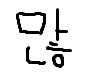

In [5]:
from IPython.display import clear_output

fileDir = '/root/Data/hangul_handwrite_val/image/test'
files = os.listdir(fileDir)

max = 10
cnt = 0

for file in files:
    if cnt > max:
        break
    
    cnt += 1
    
    clear_output()
    imageFile = fileDir + "/" +file
    print(imageFile)

    img = tf.io.read_file(imageFile)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, (64, 64))

    print(img.shape)

    img = np.array(img)

    img = np.expand_dims(img, axis=0)

    #print(img.shape)

    ch, ju, jo = model.predict(img)

    ch = ch.argmax()
    ju = ju.argmax()
    jo = jo.argmax()
    
    if ch <= 18:
        ja = label2ja[ch]
        mo = label2mo[ju]
        ba = label2ba[jo]
        
        if ju == 21:
            print(label2ja[ch])
            print(label2mo[ju])
            print(label2ba[jo])
        else:
            char = unicode.join_jamos_char(ja, mo ,ba)
            print(char)
    else:
        print(label2ja[ch])
    
    image = Image.open(imageFile)
    image.show()
    
    str = ""
    input(str)
    #os.system('cls')
    
    if (str == "exit"):
        exit()


In [6]:
import random
import matplotlib.pyplot as plt
from PIL import Image,ImageDraw,ImageFont
from IPython.display import clear_output




def getSpecificExtensionFiles(path, extension):
    out = []
    for (path, dir, files) in os.walk(path):
        for filename in files:
            ext = os.path.splitext(filename)[-1]
            if ext == extension:
                #print("%s/%s" % (path, filename))
                out.append(path + "/" + filename)
    return out

def CreateFontImage(str, fontPath):
    font = ImageFont.truetype(fontPath, 28, encoding = 'utf-8')
    left, top, right, bottom = font.getbbox(str)
    width = right - left
    height = bottom - top
    
    canvas = Image.new('RGB', (width + 10, height + 14), "white")
    draw = ImageDraw.Draw(canvas)
    draw.text((3,3), str, 'black', font)
    
    #plt.imshow(img)
    #print(img)
    
    #print(canvas)
    img = tf.image.convert_image_dtype(canvas, tf.float32)
    img = tf.image.resize(img, (64, 64))    
    
    #plt.imshow(img)
    #print(img)
    
    img = np.array(img)
    img = np.expand_dims(img, axis=0)
    

    # save the blank canvas to a file
    canvas.save("unicode-text.png", "PNG")
    canvas.show()
    return img

    
#CreateFontImage(draw_text, font)

def getFontImage(fontPath, imageNum):
    #fontFiles = getSpecificExtensionFiles(fontPath, ".ttf")
    
    #for i in range(1, imageNum):
        #fontidx = random.randrange(0, len(fontFiles) + 1)
    cho = random.randrange(0, 19)
    jung = random.randrange(0, 21)
    jong = random.randrange(0, 28)
    
    ja = label2ja[cho]
    mo = label2mo[jung]
    ba = label2ba[jong]

    char = unicode.join_jamos_char(ja, mo ,ba)
    #print(char)
    
    # label1 = np.expand_dims(np.array(cho), axis=0)
    # label2 = np.expand_dims(np.array(jung), axis=0)
    # label3 = np.expand_dims(np.array(jong), axis=0)
    print(char)

    #yield CreateFontImage(char, fontFiles[fontidx])
    return CreateFontImage (char, fontPath)#, (label1, label2, label3)

from IPython.display import clear_output

fileDir = '/root/Data/hangul_handwrite_val/image/test'
files = os.listdir(fileDir)

for file in files:
    clear_output()
    fontFiles = getSpecificExtensionFiles("/root/Data/font/clova-all", ".ttf")
    #fontFiles = getSpecificExtensionFiles("/root/Data/font/clova-all/alpha/other", ".ttf")
    fontNum = len(fontFiles)
    #print(img.shape)

    fontidx = random.randrange(0, len(fontFiles))
    print(fontFiles[fontidx])
    ch, ju, jo = model.predict(getFontImage(fontFiles[fontidx], 10))

    ch = ch.argmax()
    ju = ju.argmax()
    jo = jo.argmax()

    ja = label2ja[ch]
    mo = label2mo[ju]
    ba = label2ba[jo]

    char = unicode.join_jamos_char(ja, mo ,ba)
    print(char)

    
    str = ""
    input(str)
    #os.system('cls')
    
    if (str == "exit"):
        exit()


/root/Data/font/clova-all/옥비체/나눔손글씨옥비체.ttf
틔


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
티


In [4]:

#img = tf.io.read_file("/root/Data/hangul_handwrite_val/image/test/26.jpg")
#img = tf.io.read_file("/root/venv/Anaconda/Anaconda_Tensor/TrainData/image/20.jpg")
#img = tf.io.read_file("/root/Data/hangul_handwrite_val/image//31.jpg")
#img = tf.io.read_file("E:\\unzipData\\Training\\image_Training_handwrite\\1.letter\\040\\04030003097")
img = tf.io.read_file("/root/Data/hangul_handwrite_val/image/test/gun.jpg")
img = tf.image.decode_jpeg(img, channels=3)
img = tf.image.convert_image_dtype(img, tf.float32)
img = tf.image.resize(img, (64, 64))

print(img.shape)

img = np.array(img)

img = np.expand_dims(img, axis=0)

#print(img.shape)

ch, ju, jo = model.predict(img)

ch = ch.argmax()
ju = ju.argmax()
jo = jo.argmax()

ja = label2ja[ch]
mo = label2mo[ju]
ba = label2ba[jo]

char = unicode.join_jamos_char(ja, mo ,ba)
print(char)

NameError: name 'tf' is not defined